# Clasificacion Imagenes Perros

## Configuracion y Datos

Paquetes

In [ ]:
import os
import time
import math
import json
import shutil
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.cuda.amp as amp
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader

from torchvision import transforms, models
from torchvision.models import efficientnet_b0

from tqdm import tqdm

from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

from datasets import load_dataset

Datos

In [2]:
ds = load_dataset("dgrnd4/stanford_dog_dataset")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

stanford_dog_dataset.zip:   0%|          | 0.00/787M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20580 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20580
    })
})

Visualizamos los datos

In [3]:
dic_label = {i: j for i, j in enumerate(ds['train'].features['label'].names)}
for i in range(1, 11):
  k = random.randint(0, ds['train'].num_rows)
  raza = ds['train']['label'][k]
  print(dic_label[raza])
  img = ds['train']['image'][k]
  plt.figure(figsize = (8, 4))
  plt.imshow(img)
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Fine Tuning Modelo Pequeño

Clases de perros

In [ ]:
clases = ds['train'].features['label'].names[:10]

def clean_dog_name(full_name):
    name_part = full_name.split("-", 1)[1] if "-" in full_name else full_name
    return name_part.replace("-", "_")

cleaned_names = [clean_dog_name(name) for name in clases]

print(cleaned_names)

with open('clases_perros.json', 'w') as f:
  json.dump(cleaned_names, f)

['Chihuahua', 'Japanese_spaniel', 'Maltese_dog', 'Pekinese', 'Shih_Tzu', 'Blenheim_spaniel', 'papillon', 'toy_terrier', 'Rhodesian_ridgeback', 'Afghan_hound']


Division Train Test Simple

In [ ]:
labels = np.array(ds['train']['label'])
mask = labels < 10
ds_small_subset = ds['train'].select(np.where(mask)[0])

samples_indices = []
for label in range(10):
    label_indices = np.where(np.array(ds_small_subset['label']) == label)[0]
    np.random.seed(42)
    np.random.shuffle(label_indices)
    samples_indices.extend(label_indices[:25])

ds_small = ds_small_subset.select(samples_indices)

split_ds = ds_small.train_test_split(test_size=0.2, seed=129)
ds_train = split_ds['train']
ds_test  = split_ds['test']
print(ds_train.num_rows, ds_test.num_rows)

200 50


Preproceso simple

In [ ]:
def preprocess(example):
    img = example['image']
    img_resized = img.resize((224,224), resample=Image.NEAREST)
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    return img_array

X_train = np.array([preprocess(example) for example in ds_train])
X_test  = np.array([preprocess(example) for example in ds_test])

y_train = to_categorical([example['label'] for example in ds_train], num_classes=10)
y_test  = to_categorical([example['label'] for example in ds_test], num_classes=10)

Modelo

In [ ]:
base_model = MobileNetV2(weights = 'imagenet', include_top = False, input_shape = (224,224,3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Compilar modelo

In [ ]:
model.compile(optimizer = Adam(learning_rate = 1e-3), loss = 'categorical_crossentropy', metrics = ['accuracy'])

Entrenar modelo

In [ ]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)
model_save = ModelCheckpoint('best_model.weights.h5', monitor = 'val_loss', save_best_only = True, save_weights_only = True)
callbacks = [early_stopping, model_save]

history = model.fit(
    X_train,
    y_train,
    validation_data = (X_test, y_test),
    epochs = 20,
    callbacks = callbacks
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.1293 - loss: 2.7722 - val_accuracy: 0.5800 - val_loss: 1.2501
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5667 - loss: 1.4180 - val_accuracy: 0.8400 - val_loss: 0.6571
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6260 - loss: 0.9872 - val_accuracy: 0.8800 - val_loss: 0.4735
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.7794 - loss: 0.6689 - val_accuracy: 0.8800 - val_loss: 0.4601
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8087 - loss: 0.5193 - val_accuracy: 0.9400 - val_loss: 0.3120
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8723 - loss: 0.4364 - val_accuracy: 0.9200 - val_loss: 0.2850
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8990 - loss: 0.3776 - val_accuracy: 0.9000 - val_loss: 0.2550
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8997 - loss: 0.2700 - val_accuracy: 0.9600 - val_loss: 0

Visualizar resultados

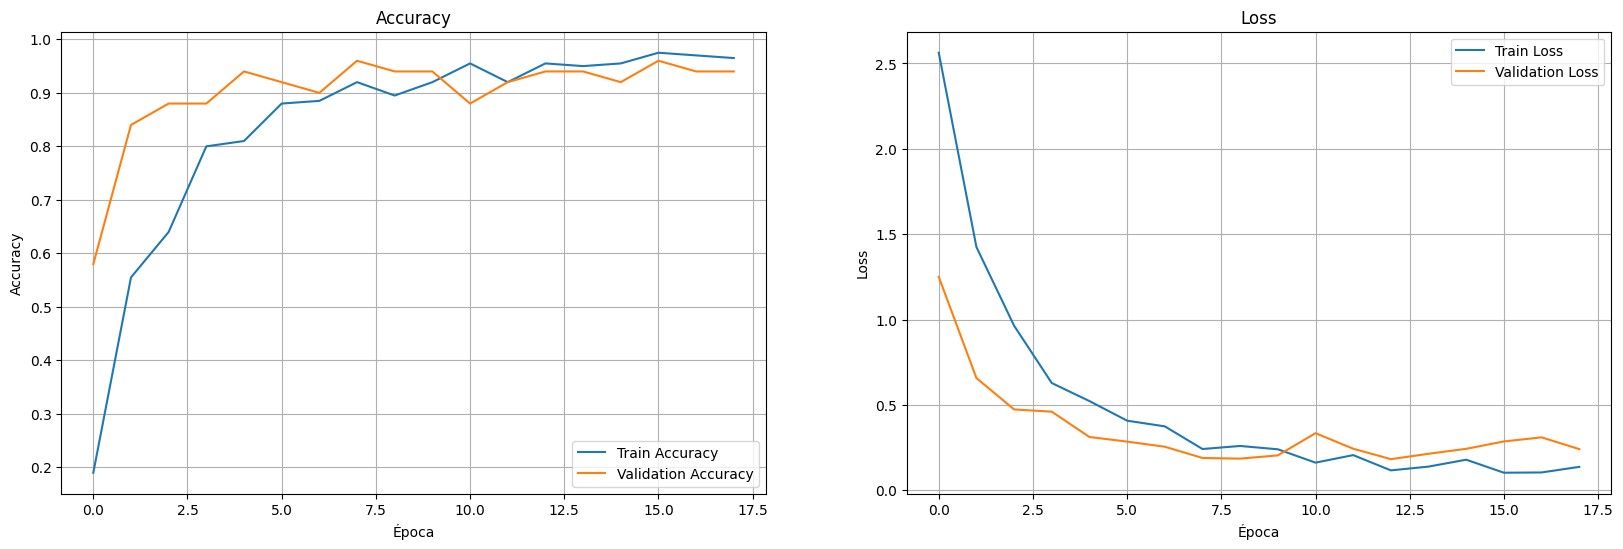

In [ ]:
plt.figure(figsize = (20, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

plt.title('Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')

plt.title('Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Ajuste de Hiperparametros

GPU

In [ ]:
torch.cuda.empty_cache()
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


Submuestra

In [ ]:
np.random.seed(42)
random.seed(42)

ds_split = ds["train"].train_test_split(test_size=0.2, seed=42)

labels = np.array(ds_split["train"]["label"])
classes = np.unique(labels)
selected_classes = np.random.choice(classes, size=10, replace=False)

train_filtered = [i for i, l in enumerate(ds_split["train"]["label"]) if l in selected_classes]
test_filtered  = [i for i, l in enumerate(ds_split["test"]["label"]) if l in selected_classes]
ds_train_small = ds_split["train"].select(train_filtered)
ds_test_small  = ds_split["test"].select(test_filtered)

def subsample_by_class(dataset, max_per_class=100):
    labels = np.array(dataset["label"])
    idxs = []
    for c in np.unique(labels):
        c_idxs = np.where(labels == c)[0]
        np.random.shuffle(c_idxs)
        idxs.extend(c_idxs[:max_per_class])
    return dataset.select(idxs)

ds_train_small = subsample_by_class(ds_train_small, 50)
ds_test_small  = subsample_by_class(ds_test_small, 10)

print("Clases seleccionadas:", selected_classes)
print("Entrenamiento:", ds_train_small.num_rows, "Test:", ds_test_small.num_rows)

label2id = {c: i for i, c in enumerate(selected_classes)}

def remap_labels(batch):
    batch["label"] = [label2id[l] for l in batch["label"]]
    return batch

ds_train_small = ds_train_small.map(remap_labels, batched=True)
ds_test_small  = ds_test_small.map(remap_labels, batched=True)

print("Mapeo de clases:", label2id)

Clases seleccionadas: [ 44  47   4  55  26  64  73  10  40 107]
Entrenamiento: 500 Test: 100
Mapeo de clases: {np.int64(44): 0, np.int64(47): 1, np.int64(4): 2, np.int64(55): 3, np.int64(26): 4, np.int64(64): 5, np.int64(73): 6, np.int64(10): 7, np.int64(40): 8, np.int64(107): 9}


Transformaciones

In [ ]:
def build_transform(aug_level="none"):
    if aug_level == "light":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    elif aug_level == "strong":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

Preprocess

In [ ]:
def preprocess(batch, transform):
    batch["pixel_values"] = [transform(img.convert("RGB")) for img in batch["image"]]
    return batch

Collate

In [ ]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "label": labels}

Simular comportamiento para evitar cierre de sesion

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Manteniendo sesión activa...");
    document.querySelector("colab-connect-button").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

Entrenar y evaluar modelo -> Random Search

In [ ]:
def train_and_eval(params):
    lr, wd, dropout, batch, aug = params["lr"], params["wd"], params["dropout"], params["batch"], params["aug"]

    # Preprocess
    transform = build_transform(aug)
    ds_train_aug = ds_train_small.with_transform(lambda b: preprocess(b, transform))
    ds_test_aug  = ds_test_small.with_transform(lambda b: preprocess(b, transform))

    # Data Loader
    train_loader = DataLoader(ds_train_aug, batch_size=batch, shuffle=True,
                              num_workers=0, pin_memory=True, collate_fn=collate_fn)
    test_loader  = DataLoader(ds_test_aug,  batch_size=batch, shuffle=False,
                              num_workers=0, pin_memory=True, collate_fn=collate_fn)

    # Modelo
    model = efficientnet_b0(weights="IMAGENET1K_V1")
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, len(selected_classes))
    )
    model = model.to(device)

    # Optimizador y pérdida
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    scaler = amp.GradScaler()  # mixed precision

    best_val_loss = float("inf")
    best_val_acc = 0.0
    no_improve = 0
    start_time = time.time()

    for epoch in range(1, 2):  # 1 epoch para tuning rápido

        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch in train_loader:
            inputs = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            with amp.autocast():  # mixed precision
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validación
        model.eval()
        val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                inputs = batch["pixel_values"].to(device)
                labels = batch["label"].to(device)
                with amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss /= len(test_loader)
        val_acc = 100 * correct_val / total_val

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= 1:
            break  # early stopping

    elapsed = time.time() - start_time
    return {
        "lr": lr, "wd": wd, "dropout": dropout, "batch": batch, "aug": aug,
        "best_val_loss": best_val_loss, "best_val_acc": best_val_acc,
        "train_acc": train_acc, "time_min": round(elapsed / 60, 2)
    }

# Sampling solo 3 hiperparámetros
def sample_params():
    return {
        "lr": 10 ** np.random.uniform(-5, -3),
        "dropout": random.choice([0.2, 0.3, 0.5]),
        "aug": random.choice(["none", "light", "strong"]),
        "batch": 16,
        "wd": 1e-5
    }

# Loop rápido de 10 trials
results = []
n_trials = 10

for i in range(n_trials):
    params = sample_params()
    print(f"\n🔹 Trial {i+1}/{n_trials} → {params}")
    res = train_and_eval(params)
    results.append(res)
    pd.DataFrame(results).to_csv("hp_tuning_results.csv", index=False)
    print(f"Resultados trial {i+1}: Val Acc = {res['best_val_acc']:.2f}% | Time = {res['time_min']} min")

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="best_val_acc", ascending=False))
print("Resultados guardados en hp_tuning_results.csv")


🔹 Trial 1/10 → {'lr': 2.1581608789405574e-05, 'dropout': 0.5, 'aug': 'none', 'batch': 16, 'wd': 1e-05}
Resultados trial 1: Val Acc = 22.00% | Time = 5.71 min

🔹 Trial 2/10 → {'lr': 2.1639062066238407e-05, 'dropout': 0.2, 'aug': 'strong', 'batch': 16, 'wd': 1e-05}
Resultados trial 2: Val Acc = 21.00% | Time = 5.25 min

🔹 Trial 3/10 → {'lr': 1.18397587687348e-05, 'dropout': 0.3, 'aug': 'none', 'batch': 16, 'wd': 1e-05}
Resultados trial 3: Val Acc = 13.00% | Time = 5.21 min

🔹 Trial 4/10 → {'lr': 0.00029703254076786893, 'dropout': 0.2, 'aug': 'none', 'batch': 16, 'wd': 1e-05}
Resultados trial 4: Val Acc = 94.00% | Time = 5.18 min

🔹 Trial 5/10 → {'lr': 0.00021262241921718471, 'dropout': 0.5, 'aug': 'none', 'batch': 16, 'wd': 1e-05}
Resultados trial 5: Val Acc = 89.00% | Time = 5.53 min

🔹 Trial 6/10 → {'lr': 8.897372054427286e-05, 'dropout': 0.5, 'aug': 'strong', 'batch': 16, 'wd': 1e-05}
Resultados trial 6: Val Acc = 70.00% | Time = 5.27 min

🔹 Trial 7/10 → {'lr': 0.0004879113241232506,

,lr,wd,dropout,batch,aug,best_val_loss,best_val_acc,train_acc,time_min
6,0.000488,0.00001,0.5,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,0.221526,97.0,61.0,5.21
7,0.000409,0.00001,0.5,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",light,0.372716,96.0,57.8,5.18
3,0.000297,0.00001,0.2,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,0.352207,94.0,65.6,5.18
9,0.000545,0.00001,0.2,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,0.194157,92.0,71.0,5.20
8,0.000148,0.00001,0.2,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,1.278412,91.0,45.8,5.70
4,0.000213,0.00001,0.5,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,1.006954,89.0,45.6,5.53
5,0.000089,0.00001,0.5,"{'pixel_values': [[tensor([[-1.0904, -0.9363, ...",strong,1.887599,70.0,23.4,5.27
0,0.000022,0.00001,0.5,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,2.192627,22.0,13.8,5.71
1,0.000022,0.00001,0.2,"{'pixel_values': [[tensor([[-1.7583, -1.7583, ...",strong,2.233364,21.0,10.4,5.25
2,0.000012,0.00001,0.3,"{'pixel_values': [[tensor([[-1.8097, -1.8268, ...",none,2.300868,13.0,13.0,5.21


Resultados guardados en hp_tuning_results.csv


Mejores hiperparametros

In [ ]:
best_params = {
    "lr": 0.0004879113241232506,
    "dropout": 0.5,
    "aug": "none",
    "batch": 16,
    "wd": 1e-5
}

## Fine Tuning Modelo Completo

GPU

In [ ]:
torch.cuda.empty_cache()
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


Transformaciones

In [ ]:
def build_transform(aug_level="none"):
    if aug_level == "light":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    elif aug_level == "strong":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

Preprocess

In [ ]:
def preprocess(batch, transform):
    batch["pixel_values"] = [transform(img.convert("RGB")) for img in batch["image"]]
    return batch

Collate

In [ ]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "label": labels}

Division Train Test

In [ ]:
np.random.seed(42)
random.seed(42)

ds_split = ds["train"].train_test_split(test_size=0.2, seed=42)
ds_train_full = ds_split["train"]
ds_test_full  = ds_split["test"]

classes = np.unique(ds_train_full["label"])
print("Número total de clases:", len(classes))

label2id = {c: i for i, c in enumerate(classes)}

def remap_labels(batch):
    batch["label"] = [label2id[l] for l in batch["label"]]
    return batch

ds_train_full = ds_train_full.map(remap_labels, batched=True)
ds_test_full  = ds_test_full.map(remap_labels, batched=True)

def subsample_by_class(dataset, n_per_class=100):
    labels = np.array(dataset["label"])
    idxs = []
    for c in np.unique(labels):
        c_idxs = np.where(labels == c)[0]
        np.random.shuffle(c_idxs)
        idxs.extend(c_idxs[:n_per_class])
    return dataset.select(idxs)

ds_train_small = subsample_by_class(ds_train_full, n_per_class=100)
ds_test_small  = subsample_by_class(ds_test_full, n_per_class=25)

print("Entrenamiento:", ds_train_small.num_rows, "imagenes")
print("Test:", ds_test_small.num_rows, "imagenes")
print("Número de clases en train:", len(np.unique(ds_train_small["label"])))
print("Número de clases en test:", len(np.unique(ds_test_small["label"])))

Número total de clases: 120


Map:   0%|          | 0/16464 [00:00<?, ? examples/s]

Map:   0%|          | 0/4116 [00:00<?, ? examples/s]

Entrenamiento: 12000 imagenes
Test: 2982 imagenes
Número de clases en train: 120
Número de clases en test: 120


Simular comportamiento para evitar cierre de sesion

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Manteniendo sesión activa...");
    document.querySelector("colab-connect-button").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

Entrenar y evaluar modelo con los mejores hiperparametros

In [ ]:
best_params = {
    "lr": 0.0004879113241232506,
    "dropout": 0.5,
    "aug": "none",
    "batch": 16,
    "wd": 1e-5
}

def train_final_model(best_params, epochs=5,
                      checkpoint_best="best_model.pth",
                      checkpoint_full="full_checkpoint.pth"):

    lr, wd, dropout, batch, aug = (
        best_params["lr"], best_params["wd"], best_params["dropout"],
        best_params["batch"], best_params["aug"]
    )

    # Preprocess
    transform = build_transform(aug)
    ds_train_aug = ds_train_small.with_transform(lambda b: preprocess(b, transform))
    ds_test_aug  = ds_test_small.with_transform(lambda b: preprocess(b, transform))

    # DataLoaders
    train_loader = DataLoader(ds_train_aug, batch_size=batch, shuffle=True,
                              num_workers=0, pin_memory=True, collate_fn=collate_fn)
    test_loader  = DataLoader(ds_test_aug,  batch_size=batch, shuffle=False,
                              num_workers=0, pin_memory=True, collate_fn=collate_fn)

    # Modelo
    model = efficientnet_b0(weights="IMAGENET1K_V1")
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, len(classes))
    )
    model = model.to(device)

    # Optimizer y Loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    # Cargar checkpoint del modelo entrenado
    start_epoch = 1
    best_val_acc = 0.0

    if os.path.exists(checkpoint_full):
        ckpt = torch.load(checkpoint_full, map_location=device)

        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scaler.load_state_dict(ckpt["scaler"])
        start_epoch = ckpt["epoch"] + 1
        best_val_acc = ckpt["best_val_acc"]

        print(f"Entrenamiento reanudado desde la época {ckpt['epoch']}.")
        print(f"Mejor accuracy previa: {best_val_acc:.2f}%")

    elif os.path.exists(checkpoint_best):
        model.load_state_dict(torch.load(checkpoint_best, map_location=device))
        print("Modelo base cargado desde best_model.pth (sin opt/esc/epoch).")
    else:
        print("No se encontró ningún checkpoint. Entrenando desde cero.")

    start_time = time.time()

    # Entrenamiento y Validacion
    for epoch in range(start_epoch, epochs + 1):

        # Entrenamiento
        model.train()
        correct, total = 0, 0
        train_loss_accum = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} Train", leave=False)

        for batch_idx, batch in enumerate(loop, start=1):
            inputs = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_accum += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix({
                "train_loss": f"{train_loss_accum/batch_idx:.4f}",
                "train_acc": f"{100*correct/total:.2f}%"
            })

        train_acc = 100 * correct / total

        # Validacion
        model.eval()
        correct_val, total_val = 0, 0
        val_loss_accum = 0
        loop_val = tqdm(test_loader, desc=f"Epoch {epoch}/{epochs} Val", leave=False)

        with torch.no_grad():
            for batch_idx, batch in enumerate(loop_val, start=1):
                inputs = batch["pixel_values"].to(device)
                labels = batch["label"].to(device)

                with autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                val_loss_accum += loss.item()
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

                loop_val.set_postfix({
                    "val_loss": f"{val_loss_accum/batch_idx:.4f}",
                    "val_acc": f"{100*correct_val/total_val:.2f}%"
                })

        val_acc = 100 * correct_val / total_val
        print(f"Epoch {epoch}/{epochs} → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        # Guardar mejor modelo con los pesos
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_best)

        # Guardar checkpoint completo del modelo 
        full_state = {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict(),
            "epoch": epoch,
            "best_val_acc": best_val_acc
        }
        torch.save(full_state, checkpoint_full)

    elapsed = time.time() - start_time
    print(f"Entrenamiento completado en {round(elapsed/60,2)} min. Mejor Val Acc: {best_val_acc:.2f}%")

    return model

final_model = train_final_model(best_params)

Entrenamiento reanudado desde la época 1.
Mejor accuracy previa: 69.72%


Epoch 2/5 → Train Acc: 79.82% | Val Acc: 69.48%


Epoch 3/5 Val:  64%|██████▎   | 119/187 [17:21<09:44,  8.60s/it, val_loss=1.2549, val_acc=67.33%]

## Predicciones

GPU

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

output_path = "representative_images"
os.makedirs(output_path, exist_ok=True)

cuda


Datos

In [32]:
ds = load_dataset("dgrnd4/stanford_dog_dataset")
classes = [name.split("-",1)[1].replace("-", "_").lower() for name in ds['train'].features['label'].names]

num_classes = len(classes)
print(f"{num_classes} clases detectadas")

120 clases detectadas


Clases

In [ ]:
np.random.seed(42)
random.seed(42)

ds_split = ds["train"].train_test_split(test_size=0.2, seed=42)
ds_train_full = ds_split["train"]

classes = np.unique(ds_train_full["label"])
print("Número total de clases:", len(classes))

label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}

def remap_labels(batch):
    batch["label"] = [label2id[l] for l in batch["label"]]
    return batch

ds_train_full = ds_train_full.map(remap_labels, batched=True)

Número total de clases: 120


Map:   0%|          | 0/16464 [00:00<?, ? examples/s]

Muestra

In [ ]:
def subsample_by_class(dataset, n_per_class=10):
    labels = np.array(dataset["label"])
    idxs = []
    for c in np.unique(labels):
        c_idxs = np.where(labels == c)[0]
        np.random.shuffle(c_idxs)
        idxs.extend(c_idxs[:n_per_class])
    return dataset.select(idxs)

ds_train_small = subsample_by_class(ds_train_full, n_per_class=10)

Modelo

In [ ]:
num_classes = len(classes)
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
in_features = model.classifier[1].in_features
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(in_features, num_classes)
)

checkpoint = torch.load("full_checkpoint.pth", map_location=device)
model.load_state_dict(checkpoint["model"])
model = model.to(device)
model.eval()

Transformar imagenes

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Predicciones

In [ ]:
best_images = {cls_idx: {"index": None, "score": -1.0} for cls_idx in classes}

for idx, item in tqdm(enumerate(ds_train_small), total=len(ds_train_small), desc="Procesando imágenes"):
    img = item['image'].convert("RGB")
    label_idx = item['label']

    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        score, pred_idx = torch.max(probs, 1)
        score = score.item()
        pred_idx = pred_idx.item()

    if score > best_images[pred_idx]["score"]:
        best_images[pred_idx]["score"] = score
        best_images[pred_idx]["index"] = idx

Procesando clases: 100%|██████████| 120/120 [20:11<00:00, 10.10s/it]


Exportar imagenes

In [ ]:
for cls_idx, info in best_images.items():
    if info["index"] is not None:
        img = ds_train_small[info["index"]]['image']
        breed_name = str(id2label[cls_idx]).lower().replace("-", "_")
        img_path = os.path.join(output_path, f"{breed_name}.jpg")
        img.save(img_path)
        print(f"Guardada: {breed_name}.jpg con score {best_images[cls_idx]['score']:.3f}")

print(f"Se guardaron {len(os.listdir(output_path))} imágenes representativas.")

Guardada imagen de la raza: 0 → representative_images/0.jpg
Guardada imagen de la raza: 1 → representative_images/1.jpg
Guardada imagen de la raza: 2 → representative_images/2.jpg
Guardada imagen de la raza: 3 → representative_images/3.jpg
Guardada imagen de la raza: 4 → representative_images/4.jpg
Guardada imagen de la raza: 5 → representative_images/5.jpg
Guardada imagen de la raza: 6 → representative_images/6.jpg
Guardada imagen de la raza: 7 → representative_images/7.jpg


KeyboardInterrupt: 